### Import Dependencies

In [1]:
import openai
import pandas as pd
from qdrant_client import QdrantClient, models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier,PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

### Single node graph

In [2]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Literal, Annotated, List, Any
from operator import add
import random
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str = ""

In [4]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }

In [5]:
workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()

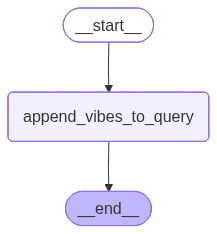

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
initial_state = {
    "message":"Give me some vibes!",
    "vibe": "I'm feeling like a badass today!"
}

In [8]:
result = graph.invoke(initial_state)

In [9]:
result

{'message': 'Give me some vibes!',
 'answer': "Give me some vibes! I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Conditional graph

In [10]:
class State(BaseModel):
    message: str
    answer: str = ""

In [11]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": state.message
    }

In [12]:
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeling like a badass today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeling like a boss today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeling like a legend today!"
    return {
        "answer": f"{state.message} {vibe}"
    }
       

In [13]:
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)
    return vibe_path

In [14]:
workflow = StateGraph(State)

workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    START,
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3"
    }
)

workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)


graph = workflow.compile()

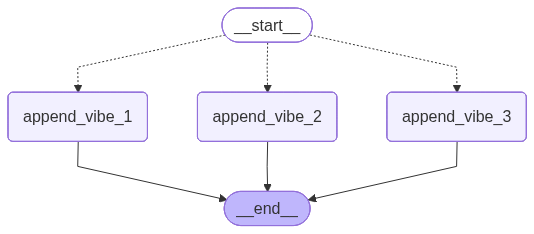

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
initial_state = {
    "message":"I am here to add some vibes!",
}

In [17]:
result = graph.invoke(initial_state)

In [18]:
result

{'message': 'I am here to add some vibes!',
 'answer': "I am here to add some vibes! I'm feeling like a legend today!"}

In [19]:
result = graph.invoke(initial_state)

In [20]:
result

{'message': 'I am here to add some vibes!',
 'answer': "I am here to add some vibes! I'm feeling like a legend today!"}

### Exploring LangChain tool calling

In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [4]:
@tool
def dummy_tool(a: str, b: str) -> str:
    """
    Concatenate two strings
    Args:
        a: The first string to concatenate
        b: The second string to concatenate
    Returns:
        A string of the two concatenated strings
    """
    return f"Hello {a} and {b}"

In [5]:
llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort = "none",
    use_responses_api=True,
)

llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)

In [6]:
response = llm_with_tools.invoke("Use dummy tool to concatenate two random words")

In [7]:
response

AIMessage(content=[{'arguments': '{"a":"orbit","b":"ember"}', 'call_id': 'call_48WGgNYgMXj8fB8yYTvWRKpL', 'name': 'dummy_tool', 'type': 'function_call', 'id': 'fc_05007975e3d725fa006a514a601c8081928a68ba6227231435', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_05007975e3d725fa006a514a5f6fa88192bcc3c401518171cb', 'created_at': 1783712351.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_05007975e3d725fa006a514a5f6fa88192bcc3c401518171cb', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'orbit', 'b': 'ember'}, 'id': 'call_48WGgNYgMXj8fB8yYTvWRKpL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 23, 'total_tokens': 108, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [8]:
response.usage_metadata

{'input_tokens': 85,
 'output_tokens': 23,
 'total_tokens': 108,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [9]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'a': 'orbit', 'b': 'ember'},
  'id': 'call_48WGgNYgMXj8fB8yYTvWRKpL',
  'type': 'tool_call'}]

### Agent Graph

In [43]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """
    Takes in a query and a vibe and returns a new query with the vibe appended
    Args:
        query: The query to append vibes to
        vibe: The vibe to append to the query
    Returns:
        A string of the query with the vibe appended
    """
    return f"{query} {vibe}"

In [44]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [45]:
def agent_node(state: State) -> dict:
    prompt_template = f"""
    You are a helpful assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query

    ## User Query
    {{query}}
    """

    template = Template(prompt_template)
    prompt = template.render(query=state.query)

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort = "none",
        use_responses_api=True,
    )

    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice="auto"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
        ]
    )

    return {
        "messages": [response]
    }

In [46]:
def tool_router(state: State) -> str:
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [47]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_edge(START, "agent_node")
workflow.add_node("tool_node", tool_node)
workflow.add_node('agent_node', agent_node)
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", END)

graph = workflow.compile()

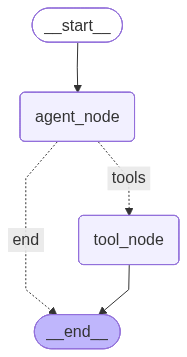

In [48]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
initial_state = {
    "query": "Give me some vibes!"
}

In [50]:
result = graph.invoke(initial_state)

In [51]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content=[{'arguments': '{"query":"{query}","vibe":"with a random playful, slightly whimsical vibe"}', 'call_id': 'call_AitAIIfkVJuFemeD3cLcLLmN', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_05fbeb0df8108ff3006a514c337a0c81929ea991c44227169a', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_05fbeb0df8108ff3006a514c32f77c8192903c935405d3d233', 'created_at': 1783712819.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_05fbeb0df8108ff3006a514c32f77c8192903c935405d3d233', tool_calls=[{'name': 'append_vibes', 'args': {'query': '{query}', 'vibe': 'with a random playful, slightly whimsical vibe'}, 'id': 'call_AitAIIfkVJuFemeD3cLcLLmN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 150, 'output_tokens': 33, 't

### Agent Graph with loopback from tools (ReAct agent)

In [52]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """
    Takes in a query and a vibe and returns a new query with the vibe appended
    Args:
        query: The query to append vibes to
        vibe: The vibe to append to the query
    Returns:
        A string of the query with the vibe appended
    """
    return f"{query} {vibe}"

In [54]:
class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [ ]:
def agent_node(state: State) -> dict:
    prompt_template = f"""
    You are a helpful assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query
    - You must call a tool in the first interaction
    """

    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort = "none",
        use_responses_api=True,
    )

    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse], #FinalResponse is a tool that acts as structured output
        tool_choice="auto"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages #this lets the model reference the previous messages (the history)
        ]
    )

    final_answer = False
    answer = ""

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get('name') == "FinalResponse":
                final_answer = True
                answer = tool_call.get('args').get('answer')
                

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer
    }

In [73]:
def tool_router(state: State) -> str:
    if state.final_answer == True:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [74]:
workflow = StateGraph(State)

tools = [append_vibes, FinalResponse]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node('agent_node', agent_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

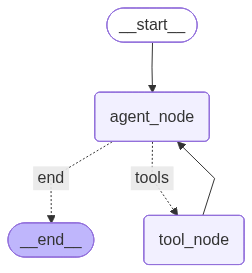

In [75]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [76]:
initial_state = {}


In [77]:
result = graph.invoke(initial_state)

In [78]:
result

{'messages': [AIMessage(content=[{'arguments': '{"query":"the user\'s query","vibe":"with a playful, neon-soaked, cyberpunk flair"}', 'call_id': 'call_rND5k5loI0d5Vonkh90uitZk', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0fbe6e51fd2e6fd4006a515119e71c819ca3d3793f680c587d', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0fbe6e51fd2e6fd4006a51511949d4819c8a37ae0ba315416a', 'created_at': 1783714073.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0fbe6e51fd2e6fd4006a51511949d4819c8a37ae0ba315416a', tool_calls=[{'name': 'append_vibes', 'args': {'query': "the user's query", 'vibe': 'with a playful, neon-soaked, cyberpunk flair'}, 'id': 'call_rND5k5loI0d5Vonkh90uitZk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 167, 'output_tokens': 36, 'total_tokens': 203,